# Mapeamento e Visualização da Rede de Postes de SJC

## Carregando e Filtrando os dados espaciais

In [5]:
import geopandas as gpd

camada_alvo = "PONNOT"
codigo_muni = "3549904"

gdf = gpd.read_file("./data/EDP_SP_391_2025-12-31_V11_20260830-0340.gdb", layer=camada_alvo)

gdf_municipio = gdf[gdf["MUN"] == codigo_muni].copy()

print(f"Total de registros na camada original: {len(gdf)}")
print(f"Total de registros no município ({codigo_muni}): {len(gdf_municipio)}")

Total de registros na camada original: 655582
Total de registros no município (3549904): 89274


## Mapa estático dos postes do municipio

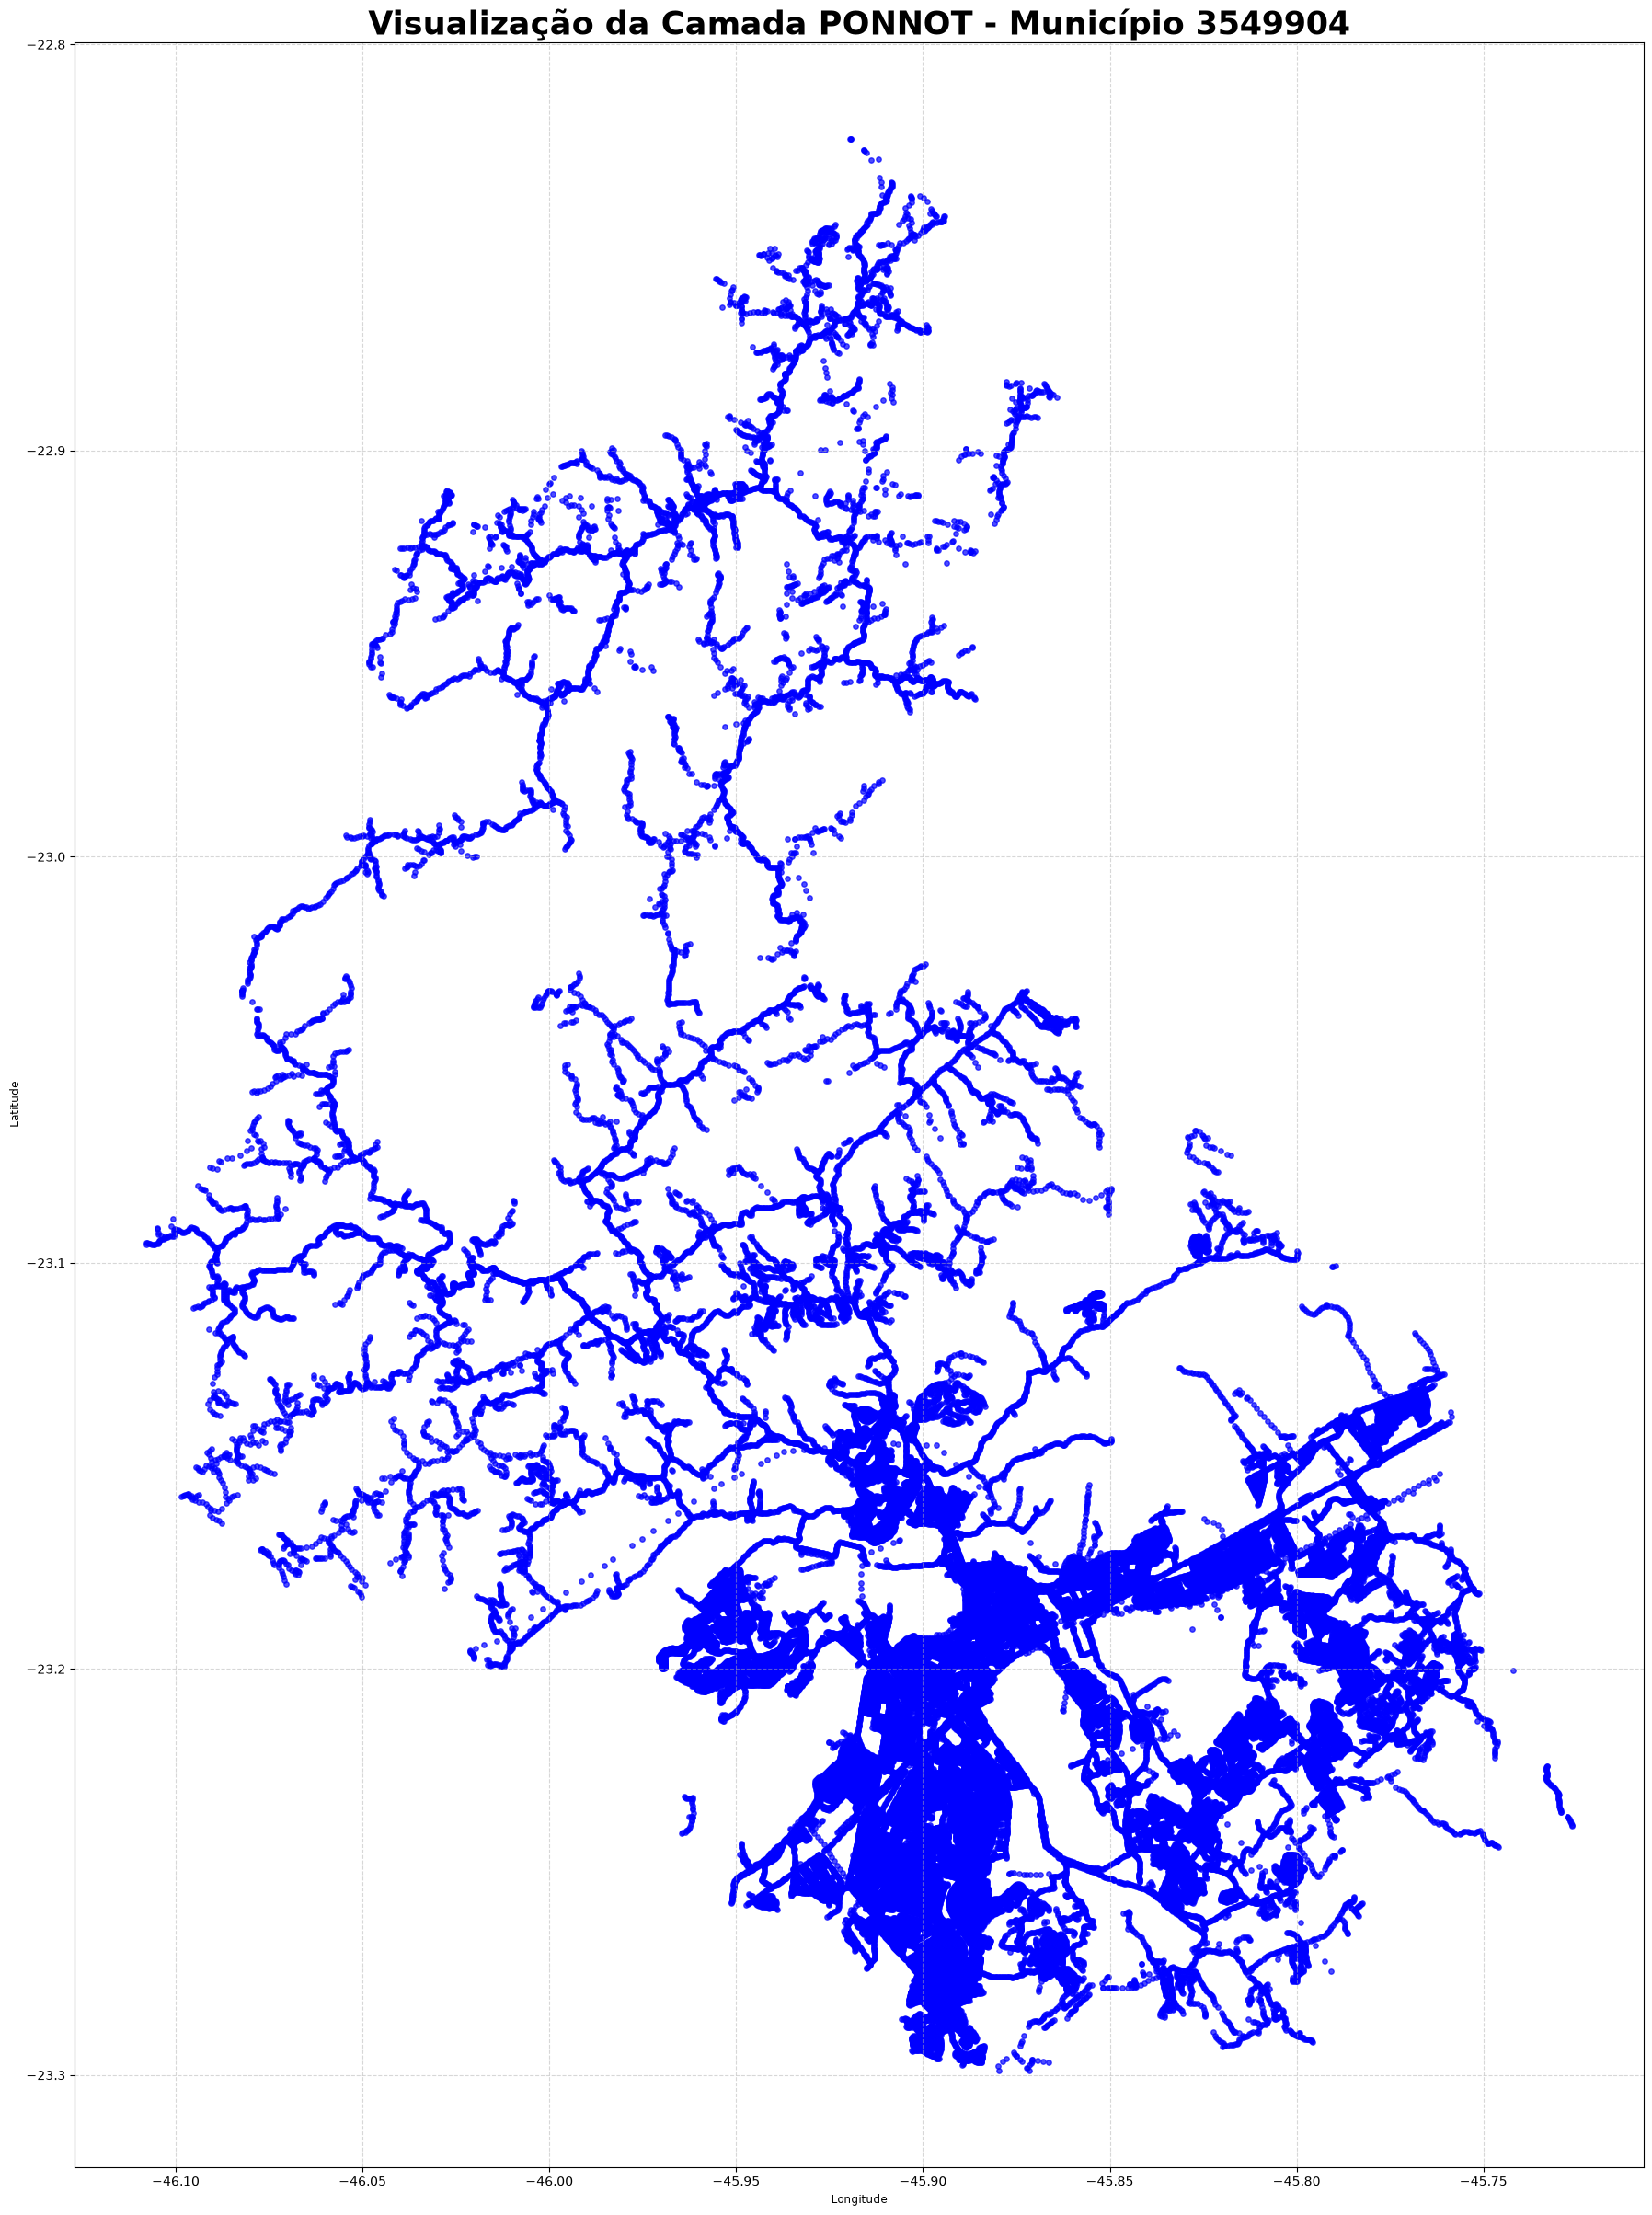

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(30, 30))

gdf_municipio.plot(
    ax=ax,
    color="blue",
    markersize=15,
    alpha=0.7,
)

ax.set_title(
    f"Visualização da Camada {camada_alvo} - Município {codigo_muni}",
    fontsize=25,
    fontweight="bold"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.grid(True, linestyle="--", alpha=0.5)

plt.show()

## Mapa interativo com a densidade geral de postes do municipio

In [7]:
import folium
from folium.plugins import HeatMap

coords = list(zip(gdf_municipio.geometry.y, gdf_municipio.geometry.x))

centro_lat = gdf_municipio.geometry.y.mean()
centro_lon = gdf_municipio.geometry.x.mean()

mapa_calor = folium.Map(
    location=[centro_lat, centro_lon],
    zoom_start=12,
    tiles="OpenStreetMap",
)

HeatMap(coords, radius=12, blur=15, min_opacity=0.4).add_to(mapa_calor)

mapa_calor

## Mapa interativo da densidade de postes por $km^2$

In [8]:
import numpy as np
import shapely.geometry as sg

gdf_utm = gdf_municipio.to_crs(epsg=31983)

tamanho_celula = 500

xmin, ymin, xmax, ymax = gdf_utm.total_bounds
cols = np.arange(xmin, xmax, tamanho_celula)
rows = np.arange(ymin, ymax, tamanho_celula)

poligonos = []
for x in cols:
    for y in rows:
        poligonos.append(sg.box(x, y, x + tamanho_celula, y + tamanho_celula))

grid = gpd.GeoDataFrame({'geometry': poligonos}, crs="EPSG:31983")

postes_na_grade = gpd.sjoin(gdf_utm, grid, how="inner", predicate="within")
contagem = postes_na_grade.groupby('index_right').size()

grid['qtd_postes'] = contagem
grid['qtd_postes'] = grid['qtd_postes'].fillna(0)

area_km2 = (tamanho_celula * tamanho_celula) / 1_000_000
grid['densidade_km2'] = grid['qtd_postes'] / area_km2

grid_com_postes = grid[grid['qtd_postes'] > 0].to_crs(epsg=4674)

mapad = grid_com_postes.explore(
    column="densidade_km2",
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"caption": "Densidade (Postes / km²)"},
    tiles="OpenStreetMap",
    name="Densidade de Postes"
)

mapad